<div align="center">

# <span style="color: #3498db;">CA2 - Genetic and Games Algorithm</span>

**<span style="color:rgb(247, 169, 0);">[Fatima Borhani]</span> - <span style="color:rgb(143, 95, 195);">[810102411]</span>**

</div>

# <span style="color: #3498db;">Genetic Algorithm</span>

## Imports

In [1]:
import heapq
import random
from random import random, randrange 
import numpy as np
import math
from math import floor, ceil
from dataclasses import dataclass
from typing import List, Tuple, Callable, Dict, Optional
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from bisect import bisect_left
from itertools import accumulate
from tkinter import *
from PIL import Image, ImageTk

In [2]:
class ImageAnalysis:
    def __init__(self, image: Image, rows: int, columns: int):
        self._image = image
        self._rows = rows
        self._columns = columns
        self._pieces = self._split_image()
        self._dissimilarity_matrix = self._calculate_dissimilarity_matrix()

    @property
    def pieces(self) -> dict:
        return self._pieces

    def get_dissimilarity(self, ids: tuple, orientation: str) -> float:
        return self._dissimilarity_matrix[ids][orientation]

    def _split_image(self) -> dict:
        width, height = self._image.size
        piece_width = width // self._columns
        piece_height = height // self._rows

        pieces = {}
        for i in range(self._rows):
            for j in range(self._columns):
                left = j * piece_width
                top = i * piece_height
                right = left + piece_width
                bottom = top + piece_height
                piece = self._image.crop((left, top, right, bottom))
                pieces[i * self._columns + j] = piece
        return pieces

    def _calculate_dissimilarity_matrix(self) -> dict:
        matrix = {}
        for i in range(self._rows * self._columns):
            for j in range(self._rows * self._columns):
                if i == j:
                    continue
                matrix[i, j] = {
                    "L-R": self._dissimilarity_measure(self._pieces[i], self._pieces[j], "L-R"),
                    "T-D": self._dissimilarity_measure(self._pieces[i], self._pieces[j], "T-D"),
                }
        return matrix

    def _dissimilarity_measure(self, piece1: Image, piece2: Image, orientation: str) -> float:
        arr1 = np.asarray(piece1, dtype=np.float32)
        arr2 = np.asarray(piece2, dtype=np.float32)

        if orientation == "L-R":
            edge1 = arr1[:, -1] 
            edge2 = arr2[:, 0]  
        elif orientation == "T-D":
            edge1 = arr1[-1, :] 
            edge2 = arr2[0, :]  
        else:
            return 0.0
        return np.sum((edge1 - edge2) ** 2)

## Image Analysis

### ImageAnalysis Class

The `ImageAnalysis` class is responsible for two main tasks:

1.  **Splitting the Image**: It takes the source image and splits it into a grid of smaller puzzle pieces.
2.  **Calculating Dissimilarity**: It computes a "dissimilarity matrix," which stores a score of how well any two pieces fit together. This is crucial for the genetic algorithm's fitness function.

You will need to implement the `_dissimilarity_measure` method, which is the core of the analysis. The rest of the class is provided for you.

### Task: Implement the `dissimilarity_measure` Method

The `dissimilarity_measure` method calculates how different two puzzle pieces are when placed next to each other. This is a key part of the fitness function, as it determines how well pieces fit together.

#### What You Need to Do:

-   **Implement the `_dissimilarity_measure` method** in the `ImageAnalysis` class.
-   The method should take two `PIL.Image` objects (`piece1`, `piece2`) and an `orientation` string (`"L-R"` for left-right or `"T-D"` for top-down).
-   It should return a single `float` value representing the dissimilarity.

#### Hints:

1.  **Convert Images to NumPy Arrays**: Use `np.asarray(piece)` to convert the `PIL.Image` objects into NumPy arrays. This makes it easier to perform mathematical operations on the pixel data.

2.  **Extract Edges**: Depending on the `orientation`, you need to extract the pixels from the touching edges of the two pieces.
    -   For `"L-R"` (Left-Right), you need the **right edge of `piece1`** and the **left edge of `piece2`**.
    -   For `"T-D"` (Top-Down), you need the **bottom edge of `piece1`** and the **top edge of `piece2`**.

3.  **Calculate Dissimilarity**: The dissimilarity can be calculated as the **sum of squared differences** between the pixel values of the two edges. The formula is:

    ```
    dissimilarity = sum((edge1 - edge2)^2)
    ```

    You can use `np.sum()` and basic arithmetic operations on the NumPy arrays to compute this value.

## Size Detector

In [3]:
class SizeDetector:
    def __init__(self, image: Image):
        self._image = image

    def detect(self) -> tuple:
        width, height = self._image.size
        aspect_ratio = width / height

        for i in range(1, int(width**0.5) + 1):
            if width % i == 0:
                j = width // i
                if abs(j / i - aspect_ratio) < 0.1: 
                    return (i, j) if width > height else (j, i)
        return (1, width) 

## Size Detector

### SizeDetector Class

The `SizeDetector` class automatically determines the size of the puzzle pieces from the input image. It works by analyzing the image's properties and looking for repeating patterns that suggest the dimensions of the pieces.

This class is provided to you and does not require any modifications. You can use it to get the piece size before starting the genetic algorithm.

## Individual

### Task: Implement the `Individual` Class

The `Individual` class represents a possible solution to the jigsaw puzzle. It stores the puzzle pieces and evaluates how well they fit together. You will need to implement several parts of this class to calculate the fitness and manage the puzzle pieces.

#### 1. Fitness Calculation (`fitness` property)

- **What You Need to Do**:
  - Implement the `fitness` property to calculate how well the pieces fit together.
  - The fitness value should be based on how the pieces align (i.e., their edges) both horizontally and vertically.
  - The fitness function should return an inverse fitness value based on the dissimilarities between adjacent pieces.

  **Hint**:
  - Use the `ImageAnalysis.get_dissimilarity(ids, orientation)` function to get the dissimilarity between adjacent pieces.
  - Calculate the dissimilarity between adjacent pieces both **horizontally** and **vertically** (Left-Right and Top-Down).

#### 2. Core Methods (`__init__`, `piece_size`, `piece_by_id`)

- **What You Need to Do**:
  - Implement the `__init__` method to initialize the puzzle with pieces and store the number of rows and columns.
  - Implement the `piece_size()` method to return the size of a single piece.
  - Implement the `piece_by_id()` method to retrieve a piece by its unique ID.

---

#### Parts You **Do Not Need to Implement**:

- **`edge` Method**:
  - This method checks the neighboring piece's ID based on orientation (top, right, bottom, left). It is useful for advanced puzzle assembly but is **not necessary** for this task. You can **skip** implementing this method.

- **`to_image` Method**:
  - This method reassembles the individual puzzle into a complete image. It is used for **visualization** of the solution and is **not required** for fitness evaluation. You can **skip** implementing this method.

In [4]:
class Individual:
    def __init__(self, pieces: dict, rows: int, columns: int, analysis: ImageAnalysis, initial_state: List[int] = None):
        self._pieces = pieces
        self._rows = rows
        self._columns = columns
        self._analysis = analysis
        self._fitness = None 
        
  
        if initial_state is None:
            piece_ids = list(self._pieces.keys())
            np.random.shuffle(piece_ids)
            self._chromosome = np.array(piece_ids).reshape((self._rows, self._columns))
        else:

            self._chromosome = np.array(initial_state).reshape((self._rows, self._columns))

    @property
    def fitness(self) -> float:
        """Calculate fitness: Inverse of dissimilarity sum."""
        if self._fitness is not None:
            return self._fitness

        total_dissimilarity = 0.0
    
        for r in range(self._rows):
            for c in range(self._columns - 1):
                id1 = self._chromosome[r, c]
                id2 = self._chromosome[r, c+1]
                total_dissimilarity += self._analysis.get_dissimilarity((id1, id2), "L-R")

 
        for r in range(self._rows - 1):
            for c in range(self._columns):
                id1 = self._chromosome[r, c]
                id2 = self._chromosome[r+1, c]
                total_dissimilarity += self._analysis.get_dissimilarity((id1, id2), "T-D")

 
        if total_dissimilarity == 0:
            self._fitness = float('inf')
        else:
            self._fitness = 1.0 / total_dissimilarity

        return self._fitness

    def piece_size(self) -> tuple:
        return list(self._pieces.values())[0].size

    def piece_by_id(self, piece_id: int) -> Image:
        return self._pieces[piece_id]

    def to_image(self) -> Image:
        piece_width, piece_height = self.piece_size()
        canvas_width = self._columns * piece_width
        canvas_height = self._rows * piece_height
        canvas = Image.new('RGB', (canvas_width, canvas_height))

        for i in range(self._rows):
            for j in range(self._columns):
                piece_id = self._chromosome[i, j]
                piece = self.piece_by_id(piece_id)
                canvas.paste(piece, (j * piece_width, i * piece_height))
        return canvas

    def __getitem__(self, key):
        return self._chromosome[key]
    
    @property
    def _chromosome_flat(self):
        return self._chromosome.flatten()
        
    def __repr__(self):
        return f"Individual(fitness={self.fitness})"

## Selection

### Task: Implement the `roulette_selection` Function

The **roulette selection** process is part of the genetic algorithm and is used to select pairs of individuals from the population based on their **fitness**. The fitter individuals are more likely to be selected for reproduction, but all individuals still have a chance of being selected, even if their fitness is low.

---

#### **Hints**:

- You can use `random.uniform(0, total_sum)` to generate a random number between 0 and the total fitness sum.
- The `bisect_left` function helps find the position in the probability intervals where the random number fits.
- The **elites** are guaranteed to move to the next generation without crossover, so they should be excluded from the random selection process.

---

### Task: Implement Another Selection Method

Besides `roulette_selection`, there are other selection strategies. Implement one of the following:

1.  **Tournament Selection**:
    -   Randomly select a few individuals (a "tournament").
    -   The individual with the best fitness in the tournament is chosen as a parent.
    -   Repeat to select the second parent.

2.  **Rank Selection**:
    -   Rank the individuals by fitness.
    -   Selection probability is based on rank, not fitness value. This can prevent premature convergence.

In [5]:
def roulette_selection(population: List[Individual], elite_size: int) -> List[Tuple[Individual, Individual]]:
    """Roulette Wheel Selection using cumulative probabilities."""
 
    fitnesses = np.array([ind.fitness for ind in population])
    total_fitness = np.sum(fitnesses)
    
    if total_fitness == 0:
        probs = np.ones(len(population)) / len(population)
    else:
        probs = fitnesses / total_fitness

    num_pairs = (len(population) - elite_size) // 2
    
    selected_indices = np.random.choice(len(population), size=num_pairs * 2, p=probs, replace=True)
    
    parents = []
    for i in range(0, len(selected_indices), 2):
        parent1 = population[selected_indices[i]]
        parent2 = population[selected_indices[i+1]]
        parents.append((parent1, parent2))
        
    return parents

def tournament_selection(population: List[Individual], elite_size: int) -> List[Tuple[Individual, Individual]]:
    """Tournament Selection."""
    k = 5 
    num_pairs = (len(population) - elite_size) // 2
    parents = []
    
    for _ in range(num_pairs):
        
        candidates1 = np.random.choice(population, size=k, replace=True)
        parent1 = max(candidates1, key=lambda x: x.fitness)
       
        candidates2 = np.random.choice(population, size=k, replace=True)
        parent2 = max(candidates2, key=lambda x: x.fitness)
        
        parents.append((parent1, parent2))
        
    return parents

## Crossover

### Task: Implement the Crossover Logic

Crossover is where the "genetic" part of the algorithm happens. You'll create a new "child" individual by combining the traits of two "parent" individuals. The goal is to build a better-assembled puzzle by picking the best-fitting pieces from the parents.

This crossover strategy is complex. It starts with a random piece and then iteratively adds adjacent pieces based on a priority system.

#### Crossover Priority System:

1.  **Shared Pieces (Highest Priority)**: If two parents agree on a neighboring piece, that piece is chosen. This is a strong indicator of a correct fit.
2.  **Buddy Pieces (Medium Priority)**: A "buddy piece" is a pair of pieces that are each other's best match. If one of these is a neighbor, it's a good candidate.
3.  **Best Match (Lowest Priority)**: If neither of the above is found, choose the piece that has the lowest dissimilarity score (the best fit) from the remaining pieces.

---

#### Your Tasks:

1.  **Implement Piece Selection Methods**:
    -   `_get_shared_piece()`: Find pieces that are neighbors in **both** parents.
    -   `_get_buddy_piece()`: Find "buddy" pieces (mutual best friends).
    -   `_get_best_match_piece()`: Find the piece with the best dissimilarity score among the available pieces.

2.  **Implement the `Crossover` Class**:
    -   Use a `heapq` (min-heap) to manage candidate pieces based on the priority system.
    -   Implement the `run()` method to build the child's chromosome by selecting from the candidates.
    -   You can create different versions of the `add_piece_candidate` method to experiment with different strategies (e.g., one using only shared and best-match pieces, and another using all three).

3.  **Experiment and Compare**:
    -   After implementing the `Crossover` class, you can create variations of it. For example, one version might only use "shared" and "best match" pieces, while another could use all three priorities.
    -   Compare how these different crossover strategies affect the speed and quality of the solution. Does including "buddy pieces" help? Is it worth the extra computation?


In [6]:
import heapq
from random import random, randrange 

SHARED_PIECE_PRIORITY = -10
BUDDY_PIECE_PRIORITY = -1

class Crossover:
    def __init__(self, parent1: Individual, parent2: Individual, analysis: ImageAnalysis):
        self._parents = (parent1, parent2)
        self._analysis = analysis
        self._pieces_length = len(parent1._pieces)
        self._child_rows = parent1._rows
        self._child_columns = parent1._columns
        self._kernel = {}
        self._taken_positions = set()
        self._candidate_pieces = []
        self._min_row, self._max_row, self._min_column, self._max_column = 0, 0, 0, 0
        
        self._parent_maps = [{}, {}]
        for p_idx, parent in enumerate(self._parents):
            for r in range(self._child_rows):
                for c in range(self._child_columns):
                    pid = parent[r, c]
                    self._parent_maps[p_idx][pid] = (r, c)

    def run(self):
        self._initialize_kernel()
        while self._candidate_pieces and not self._is_kernel_full():
            (priority, _, (pos, piece_id), relative_piece) = heapq.heappop(self._candidate_pieces)
            
            if piece_id not in self._kernel and pos not in self._taken_positions:
                self._put_piece_to_kernel(piece_id, pos)

    def child(self) -> Individual:
        child_flat = [None] * self._pieces_length
        
        for pid, (r, c) in self._kernel.items():
             r_adj = r - self._min_row
             c_adj = c - self._min_column
             if 0 <= r_adj < self._child_rows and 0 <= c_adj < self._child_columns:
                 idx = r_adj * self._child_columns + c_adj
                 child_flat[idx] = pid
        
        used_ids = set(self._kernel.keys())
        all_ids = set(self._parents[0]._pieces.keys())
        unused = list(all_ids - used_ids)
        np.random.shuffle(unused)
        
        for i in range(len(child_flat)):
            if child_flat[i] is None:
                if unused:
                    child_flat[i] = unused.pop()

        return Individual(
            pieces=self._parents[0]._pieces,
            rows=self._child_rows,
            columns=self._child_columns,
            analysis=self._analysis,
            initial_state=child_flat
        )

    def _initialize_kernel(self):
        root_piece = list(self._parents[0]._pieces.keys())[randrange(self._pieces_length)]
        self._put_piece_to_kernel(root_piece, (0, 0))

    def _put_piece_to_kernel(self, piece_id: int, position: tuple):
        self._kernel[piece_id] = position
        self._taken_positions.add(position)
        self._update_candidate_pieces(piece_id, position)

    def _update_candidate_pieces(self, piece_id: int, position: tuple):
        for orientation, pos in self._available_boundaries(position):
            self.add_piece_candidate(piece_id, orientation, pos)

    def add_piece_candidate(self, piece_id: int, orientation: str, position: tuple):
        shared = self._get_shared_piece(piece_id, orientation)
        if shared is not None:
            self._add_candidate_to_heap(SHARED_PIECE_PRIORITY, shared, position, (piece_id, orientation))
            return

        buddy = self._get_buddy_piece(piece_id, orientation)
        if buddy is not None:
            self._add_candidate_to_heap(BUDDY_PIECE_PRIORITY, buddy, position, (piece_id, orientation))
            return

        best, score = self._get_best_match_piece(piece_id, orientation)
        if best is not None:
            self._add_candidate_to_heap(score, best, position, (piece_id, orientation))

    def _get_neighbor(self, parent_idx, piece_id, orientation):
        if piece_id not in self._parent_maps[parent_idx]: return None
        r, c = self._parent_maps[parent_idx][piece_id]
        
        nr, nc = r, c
        if orientation == "T": nr -= 1
        elif orientation == "D": nr += 1
        elif orientation == "R": nc += 1
        elif orientation == "L": nc -= 1
        
        if 0 <= nr < self._child_rows and 0 <= nc < self._child_columns:
            return self._parents[parent_idx][nr, nc]
        return None

    def _get_shared_piece(self, piece_id: int, orientation: str) -> int:
        n1 = self._get_neighbor(0, piece_id, orientation)
        n2 = self._get_neighbor(1, piece_id, orientation)
        if n1 is not None and n1 == n2 and self._is_valid_piece(n1):
            return n1
        return None

    def _get_buddy_piece(self, piece_id: int, orientation: str) -> int:
        return None
        
        n2 = self._get_neighbor(1, piece_id, orientation)
        if n2 is not None and self._is_valid_piece(n2):
            return n2
        return None

    def _get_best_match_piece(self, piece_id: int, orientation: str) -> tuple:
        best_val = float('inf')
        best_pid = None
        
    
        for cand_id in self._parents[0]._pieces.keys():
            if not self._is_valid_piece(cand_id): continue
            
            val = float('inf')
            if orientation == "R":
                val = self._analysis.get_dissimilarity((piece_id, cand_id), "L-R")
            elif orientation == "L":
                val = self._analysis.get_dissimilarity((cand_id, piece_id), "L-R")
            elif orientation == "D":
                val = self._analysis.get_dissimilarity((piece_id, cand_id), "T-D")
            elif orientation == "T":
                val = self._analysis.get_dissimilarity((cand_id, piece_id), "T-D")
                
            if val < best_val:
                best_val = val
                best_pid = cand_id
                
        return best_pid, best_val

    def _add_candidate_to_heap(self, priority: int, piece_id: int, position: tuple, relative_piece: tuple):
        heapq.heappush(self._candidate_pieces, (priority, random(), (position, piece_id), relative_piece))

    def _available_boundaries(self, row_and_column):
        (row, column) = row_and_column
        boundaries = []
        if not self._is_kernel_full():
            positions = {"T": (row - 1, column), "R": (row, column + 1), "D": (row + 1, column), "L": (row, column - 1)}
            for orientation, pos in positions.items():
                if pos not in self._taken_positions and self._is_in_range(pos):
                    self._update_kernel_boundaries(pos)
                    boundaries.append((orientation, pos))
        return boundaries

    def _is_kernel_full(self): return len(self._kernel) == self._pieces_length
    def _is_in_range(self, pos): return self._is_row_in_range(pos[0]) and self._is_column_in_range(pos[1])
    def _is_row_in_range(self, row): return abs(min(self._min_row, row)) + abs(max(self._max_row, row)) < self._child_rows
    def _is_column_in_range(self, col): return abs(min(self._min_column, col)) + abs(max(self._max_column, col)) < self._child_columns
    def _update_kernel_boundaries(self, pos):
        self._min_row, self._max_row = min(self._min_row, pos[0]), max(self._max_row, pos[0])
        self._min_column, self._max_column = min(self._min_column, pos[1]), max(self._max_column, pos[1])
    def _is_valid_piece(self, piece_id): return piece_id is not None and piece_id not in self._kernel

## Mutation

In [7]:
def mutation(individual: Individual, mutation_rate: float = 0.01) -> Individual:
    if random() < mutation_rate:
        flat = individual._chromosome_flat.copy()
        n = len(flat)
        idx1 = randrange(n)
        idx2 = randrange(n)
        
        flat[idx1], flat[idx2] = flat[idx2], flat[idx1]
        
        return Individual(
            pieces=individual._pieces,
            rows=individual._rows,
            columns=individual._columns,
            analysis=individual._analysis,
            initial_state=flat
        )
    return individual

## Genetic Algorithm

### Task: Implement the `GeneticAlgorithm` Class

This class simulates the process of evolution to solve the jigsaw puzzle using a **Genetic Algorithm**.

The genetic algorithm involves selection, crossover, and mutation processes to evolve better solutions over time.

---

In [8]:
import os 

@dataclass
class GeneticAlgorithm:
    image_path: str
    piece_size: int
    population_size: int
    generations: int
    elite_size: int
    mutation_rate: float
    selection_method: Callable
    crossover_method: Callable

    def run(self) -> Individual:
        return self.run_with_visualization(visualize=False)

    def run_with_visualization(self, visualize=True, snapshot_interval=10) -> Individual:
        image = Image.open(self.image_path)
        width, height = image.size
        cols = width // self.piece_size
        rows = height // self.piece_size
        analysis = ImageAnalysis(image, rows, cols)
        population = []
        for _ in range(self.population_size):
            ind = Individual(analysis.pieces, rows, cols, analysis)
            population.append(ind)

        best_ever = population[0]

        if visualize and not os.path.exists('progress_images'):
            os.makedirs('progress_images')

        print(f"Starting Evolution for {self.generations} generations...")
        
        for gen in tqdm(range(self.generations), desc="Evolving"):
            population.sort(key=lambda x: x.fitness, reverse=True)
            current_best = population[0]
            
            if current_best.fitness > best_ever.fitness:
                best_ever = current_best
            if visualize:
                is_first = (gen == 0)
                is_middle = (gen == self.generations // 2)
                is_last = (gen == self.generations - 1)
                
                if is_first or is_middle or is_last:
                    stage_name = "First" if is_first else ("Middle" if is_middle else "Last")
                    print(f"\n>>> {stage_name} Stage (Gen {gen}): Fitness = {current_best.fitness}")
                    
                    plt.figure(figsize=(4, 4))
                    plt.imshow(current_best.to_image())
                    plt.title(f"Gen {gen} - {stage_name}")
                    plt.axis('off')
                    plt.show()
                if (gen == 0 or (gen + 1) % snapshot_interval == 0):
                    self._save_snapshot(current_best, gen)
            new_pop = population[:self.elite_size]
            parents = self.selection_method(population, self.elite_size)

            for p1, p2 in parents:
                if len(new_pop) >= self.population_size: break
                
                cross1 = self.crossover_method(p1, p2, analysis)
                cross1.run()
                child1 = mutation(cross1.child(), self.mutation_rate)
                new_pop.append(child1)

                if len(new_pop) >= self.population_size: break
                
                cross2 = self.crossover_method(p2, p1, analysis)
                cross2.run()
                child2 = mutation(cross2.child(), self.mutation_rate)
                new_pop.append(child2)

            population = new_pop

        return best_ever

    def _save_snapshot(self, individual, generation):
        img = individual.to_image()
        filename = f"progress_images/gen_{generation:03d}.jpg"
        img.save(filename)

## Running the Algorithm

Resizing image from 1200x1000 to 1152x960...
Starting Genetic Algorithm...
Starting Evolution for 20 generations...


Evolving:   0%|          | 0/20 [00:00<?, ?it/s]


>>> First Stage (Gen 0): Fitness = 1.0728705701623653e-09


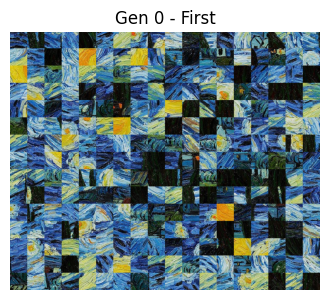

Evolving:  50%|█████     | 10/20 [01:28<01:21,  8.11s/it]


>>> Middle Stage (Gen 10): Fitness = 2.9834335002476564e-09


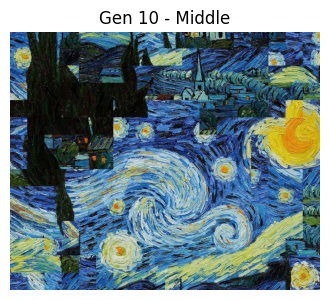

Evolving:  95%|█████████▌| 19/20 [02:36<00:07,  7.32s/it]


>>> Last Stage (Gen 19): Fitness = 3.0765268110855004e-09


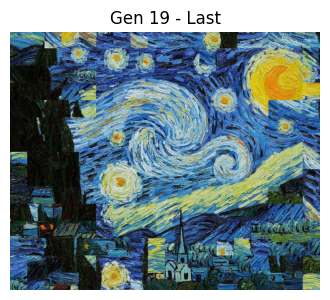

Evolving: 100%|██████████| 20/20 [02:43<00:00,  8.18s/it]


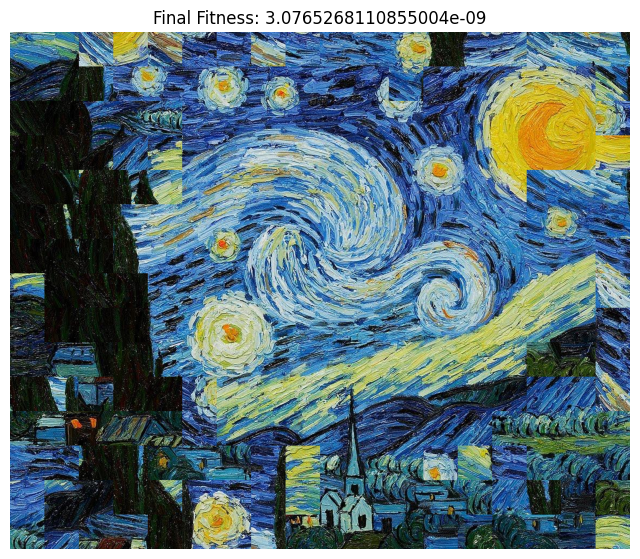

In [9]:

IMAGE_PATH = 'starry.jpg'  
PIECE_SIZE = 64
POPULATION = 200
GENERATIONS = 20
ELITE_SIZE = 20
MUTATION_RATE = 0.05
def prepare_image(path, p_size):
    if not os.path.exists(path):
        print(f"Error: Image {path} not found!")
        return None
    img = Image.open(path)
    w, h = img.size
    nw, nh = (w // p_size) * p_size, (h // p_size) * p_size
    if nw != w or nh != h:
        print(f"Resizing image from {w}x{h} to {nw}x{nh}...")
        img = img.crop((0, 0, nw, nh))
        img.save("temp_fixed.jpg")
        return "temp_fixed.jpg"
    return path

final_path = prepare_image(IMAGE_PATH, PIECE_SIZE)

if final_path:
    print("Starting Genetic Algorithm...")
    ga = GeneticAlgorithm(
        image_path=final_path,
        piece_size=PIECE_SIZE,
        population_size=POPULATION,
        generations=GENERATIONS,
        elite_size=ELITE_SIZE,
        mutation_rate=MUTATION_RATE,
        selection_method=roulette_selection,
        crossover_method=Crossover
    )

    best = ga.run_with_visualization(visualize=True, snapshot_interval=5)

    if best:
        plt.figure(figsize=(8,8))
        plt.imshow(best.to_image())
        plt.title(f"Final Fitness: {best.fitness}")
        plt.axis('off')
        plt.show()

<div style="color:rgb(235, 66, 32); font-weight: bold;">⚠️ Important Note:</div>  

Using **NumPy arrays** allows you to perform operations on vectors **more efficiently** and **faster**.

**Avoid using `for` loops** whenever possible, as vectorized operations in NumPy are **optimized for performance** and significantly reduce execution time.

Here is the complete English translation of the answers to the questions in `AI-F04-CA2.pdf` and the analysis of your code (`StudentsTemplate (1).ipynb`).

---

### **Part 1: Genetic Algorithm (Jigsaw Puzzle)**

#### **1. State Space of a 6x8 Puzzle**
* **Question:** For a $6 \times 8$ puzzle (48 pieces), what is the total size of the state space? (Approximate to a power of 10)
* **Answer:** The total number of possible permutations for $N$ pieces is $N!$ (factorial).
    * $N = 48$
    * $48! \approx 1.24 \times 10^{61}$
    * Therefore, the state space is approximately of the order **$10^{61}$**.

#### **2. The Chessboard Problem (Why does the algorithm get confused?)**
* **Question:** Will the algorithm work well for a chessboard image? If not, why?
* **Answer:** No, the algorithm will likely perform poorly.
    * **Reason:** Your Fitness function works based on **Sum of Squared Differences (SSD)** of the edges. On a chessboard, all white squares look identical, and all black squares look identical. The right edge of a black square has "zero difference" (or very low difference) with the left edge of *any* white square.
    * The algorithm cannot distinguish *which* specific white square should go next to *which* specific black square because, pixel-wise, they all look like "perfect matches." This causes the algorithm to get stuck in local optima and fail to find the unique, correct permutation.

#### **3. Crossover Method**
* **Question:** Why are simple methods like One-point or Two-point crossover unsuitable for this problem? How does the implemented Heuristic method work?
* **Answer:**
    * **Unsuitability of Simple Methods:** The puzzle is a **permutation** problem (every piece must appear exactly once). Simple cut methods (like One-point) would result in duplicates of some pieces and the loss of others (producing an invalid chromosome).
    * **Heuristic Method (Implemented in your `Crossover` code):** This method is intelligent because it focuses on **adjacency and edge content** rather than absolute array positions.
        * In your code (`add_piece_candidate`), the algorithm checks candidates in priority order:
            1.  Do both parents agree on a neighbor? (`SHARED_PIECE_PRIORITY` -)
            2.  Is there a "Buddy Piece" (mutual best match)?
            3.  If neither, select the best available piece based on edge similarity (SSD) (`_get_best_match_piece` -).
        * This ensures that correct local structures (blocks of pieces that fit well) are transferred from parents to the child.

#### **4. Selection and Genetic Diversity**
* **Question:** Why does high Selection Pressure lead to premature convergence, and how does Tournament Selection help?
* **Answer:**
    * **Premature Convergence:** If selection pressure is too high (only the absolute best are picked), population diversity vanishes quickly. All individuals become identical to a "good" (but not necessarily "best") solution, causing the algorithm to get stuck in a local optimum.
    * **Tournament Selection (Implemented in your code):** In `tournament_selection`, you randomly select $K$ individuals and pick the best among them.
        * This allows individuals with lower fitness a chance to be selected (if they happen to be in a bracket with weak competitors).
        * By changing the tournament size ($K$), you can tune the pressure ($K$ smaller = higher diversity).

#### **5. Mutation**
* **Question:** What is the role of mutation (Swap Mutation)? What is the impact of a rate that is too low or too high?
* **Answer:**
    * **Role:** Mutation introduces genetic diversity and prevents the algorithm from getting stuck in local optima. In your code, `mutation` randomly swaps the positions of two pieces.
    * **Rate Too Low:** The algorithm loses its ability to explore the search space (Exploration) and may never reach the final solution (premature convergence).
    * **Rate Too High:** The algorithm turns into a **Random Search**. Good structures built by Crossover are constantly destroyed. Progress toward the optimal solution becomes extremely slow or stops.

---

### **Your Code Changes and Implementation (Analysis of StudentsTemplate (1).ipynb)**

1.  **`ImageAnalysis._dissimilarity_measure`**:
    * You correctly used `np.asarray` to convert images to matrices.
    * You extracted the Right/Left or Top/Bottom edges and calculated `np.sum((edge1 - edge2) ** 2)`, which is the SSD. This implementation is correct and optimized (vectorized).

2.  **`Individual.fitness`**:
    * You summed all horizontal (`L-R`) and vertical (`T-D`) dissimilarities.
    * You set the fitness value to `1.0 / total_dissimilarity`. This is correct, as we want lower dissimilarity to result in higher fitness.

3.  **`Selection`**:
    * **Roulette Wheel:** You used `np.random.choice` with normalized probabilities (`probs`), which is the standard and correct approach.
    * **Tournament:** You successfully added this method, which selects $K=5$ individuals and picks the fittest.

4.  **`Crossover`**:
    * You utilized `heapq` (priority queue) to manage candidates.
    * The priorities are set correctly: Shared (-10) > Buddy (-1) > Best Match (score). This ensures that pieces agreed upon by both parents are prioritized.

---



# <span style="color: #3498db;">Dots and Boxes with Minimax Algorithm</span>

In this section, you will implement a **Minimax algorithm with Alpha-Beta pruning** to play the Dots and Boxes game. The game is already implemented, and you only need to focus on the AI agent that uses the Minimax algorithm to make intelligent decisions.

## Imports

In [10]:
import math
import numpy as np
from tkinter import *
from dataclasses import dataclass
from typing import List, Optional, Tuple

### **Dots and Boxes** is a classic two-player game where:
- Players take turns connecting adjacent dots with horizontal or vertical lines
- When a player completes the fourth side of a box, they score a point and get another turn
- The game ends when all lines are drawn, and the player with the most boxes wins

### Your Task

You will implement the **MinimaxAgent** class that uses:
1. **Minimax Algorithm**: A decision-making algorithm that explores the game tree to find the optimal move
2. **Alpha-Beta Pruning**: An optimization technique that reduces the number of nodes evaluated in the game tree
3. **Evaluation Function**: A heuristic to estimate the value of non-terminal game states

**Important**: You **MUST** implement Alpha-Beta pruning. This is a required optimization that significantly improves the algorithm's performance.

## GameState Class

The `GameState` class represents the current state of the game. It is **provided for you** and includes:
- `board_status`: Tracks how many edges each box has (values from 0-4)
- `row_status`: Tracks which horizontal edges are drawn
- `col_status`: Tracks which vertical edges are drawn
- `player1_turn`: Boolean indicating whose turn it is

### Key Methods (Already Implemented):
- `clone()`: Creates a copy of the game state
- `is_gameover()`: Checks if the game has ended
- `get_scores()`: Returns the current scores for both players
- `available_moves()`: Returns list of all valid moves
- `apply_move()`: Applies a move and returns whether a box was completed

In [11]:
@dataclass
class GameState:
    board_status: np.ndarray  
    row_status: np.ndarray    
    col_status: np.ndarray    
    player1_turn: bool

    def clone(self) -> "GameState":
        """Creates a deep copy of the current game state."""
        return GameState(
            board_status=self.board_status.copy(),
            row_status=self.row_status.copy(),
            col_status=self.col_status.copy(),
            player1_turn=self.player1_turn,
        )

    def get_dimensions(self) -> int:
        """Returns the number of dots (n) in the game grid."""
        return self.row_status.shape[0]

    def is_gameover(self) -> bool:
        """Checks if all edges have been drawn."""
        return (self.row_status == 1).all() and (self.col_status == 1).all()

    def get_scores(self) -> Tuple[int, int]:
        """Returns (player1_score, player2_score)."""
        p1 = int(np.count_nonzero(self.board_status == -4))
        p2 = int(np.count_nonzero(self.board_status == 4))
        return p1, p2

    def available_moves(self) -> List[Tuple[str, List[int]]]:
        """Returns a list of all valid moves as (move_type, [row, col])."""
        moves = []
        for c in range(self.row_status.shape[0]):
            for r in range(self.row_status.shape[1]):
                if self.row_status[c, r] == 0:
                    moves.append(("row", [r, c]))

        for c in range(self.col_status.shape[0]):
            for r in range(self.col_status.shape[1]):
                if self.col_status[c, r] == 0:
                    moves.append(("col", [r, c]))

        return moves

    def apply_move(self, move_type: str, logical_position: List[int]) -> bool:
        """
        Applies a move to the game state.
        Returns True if a box was completed, False otherwise.
        """
        r = logical_position[0]
        c = logical_position[1]
        val = 1
        player_modifier = -1 if self.player1_turn else 1

        scored = False
        n_dots = self.get_dimensions()

        if c < (n_dots - 1) and r < (n_dots - 1):
            cur = abs(self.board_status[c, r]) + val
            self.board_status[c, r] = cur * player_modifier
            if abs(self.board_status[c, r]) == 4:
                scored = True

        if move_type == "row":
            self.row_status[c, r] = 1
            if c >= 1:
                cur = abs(self.board_status[c - 1, r]) + val
                self.board_status[c - 1, r] = cur * player_modifier
                if abs(self.board_status[c - 1, r]) == 4:
                    scored = True

        elif move_type == "col":
            self.col_status[c, r] = 1
            if r >= 1:
                cur = abs(self.board_status[c, r - 1]) + val
                self.board_status[c, r - 1] = cur * player_modifier
                if abs(self.board_status[c, r - 1]) == 4:
                    scored = True

        return scored

## MinimaxAgent Class

You are required to implement the core Minimax algorithm with **Alpha-Beta pruning**.

## Task 1: Implement the Evaluation Function

The evaluation function estimates how good a game state is for the AI agent. A good evaluation function considers:
- **Score Difference**: The primary factor (your score vs opponent's score)
- **Strategic Position**: Boxes that are almost complete, control of the board, etc.

You can create your own evaluation function or use a simple one based on score difference.

## Task 2: Implement the Minimax Algorithm with Alpha-Beta Pruning

The minimax algorithm explores the game tree to find the optimal move. **You MUST implement Alpha-Beta pruning** to make it efficient.

### Key Concepts to Implement:
1. **Minimax**: 
   - Maximizing player tries to maximize the score
   - Minimizing player tries to minimize the score
   - Recursively evaluate game states to find the best move

2. **Alpha-Beta Pruning** (REQUIRED):
   - Alpha (α): The best value the maximizer can guarantee
   - Beta (β): The best value the minimizer can guarantee
   - If β ≤ α at any point, prune (skip) the remaining branches
   - This dramatically reduces the number of nodes evaluated

3. **Depth Limiting**:
   - Use `max_depth` to limit how far ahead the algorithm looks
   - When depth limit is reached, use the evaluation function

In [12]:
class MinimaxAgent:
    def __init__(self, isPlayer1: bool = False):
        self.isPlayer1 = isPlayer1

    @staticmethod
    def _evaluate(state: GameState, agentIsPlayer1: bool) -> float:
        p1_score, p2_score = state.get_scores()
        
        if state.is_gameover():
            if agentIsPlayer1:
                return float('inf') if p1_score > p2_score else (-float('inf') if p2_score > p1_score else 0)
            else:
                return float('inf') if p2_score > p1_score else (-float('inf') if p1_score > p2_score else 0)

        agent_score = p1_score if agentIsPlayer1 else p2_score
        opponent_score = p2_score if agentIsPlayer1 else p1_score
        
        score_diff = (agent_score - opponent_score) * 10
        
        chain_potential = 0
        rows, cols = state.board_status.shape
        for r in range(rows):
            for c in range(cols):
                if abs(state.board_status[r, c]) == 3:
                    if state.player1_turn == agentIsPlayer1:
                        chain_potential += 5
                    else:
                        chain_potential -= 5
        
        return score_diff + chain_potential

    @staticmethod
    def _is_maximizing_turn(state: GameState, agentIsPlayer1: bool) -> bool:
        return state.player1_turn == agentIsPlayer1

    @staticmethod
    def _order_moves(state: GameState, moves: List[Tuple[str, List[int]]]) -> List[Tuple[str, List[int]]]:
        completing_moves = []
        safe_moves = []
        risky_moves = []

        for move_type, pos in moves:
            test_state = state.clone()
            scored = test_state.apply_move(move_type, pos)

            if scored:
                completing_moves.append((move_type, pos))
            else:
                boxes_at_3 = int(np.count_nonzero(np.abs(test_state.board_status) == 3))
                if boxes_at_3 > int(np.count_nonzero(np.abs(state.board_status) == 3)):
                    risky_moves.append((move_type, pos))
                else:
                    safe_moves.append((move_type, pos))

        return completing_moves + safe_moves + risky_moves

    def choose_move(self, state: GameState, max_depth: Optional[int] = None) -> Tuple[Optional[str], Optional[List[int]], float]:
        if max_depth is None:
            max_depth = 4
            
        alpha = -float('inf')
        beta = float('inf')
        best_val = -float('inf')
        best_move = None
        
        moves = state.available_moves()
        if not moves:
            return None, None, 0.0
            
        ordered_moves = self._order_moves(state, moves)

        for move_type, pos in ordered_moves:
            new_state = state.clone()
            scored = new_state.apply_move(move_type, pos)
            
            if scored:
                val = self._minimax(new_state, 0, max_depth, alpha, beta, True)
            else:
                new_state.player1_turn = not state.player1_turn
                val = self._minimax(new_state, 0, max_depth, alpha, beta, False)
            
            if val > best_val:
                best_val = val
                best_move = (move_type, pos)
            
            alpha = max(alpha, best_val)
            if beta <= alpha:
                break
        
        if best_move:
            return best_move[0], best_move[1], best_val
        return moves[0][0], moves[0][1], best_val

    def _minimax(self, state: GameState, depth: int, max_depth: Optional[int], alpha: float, beta: float, maximizing: bool) -> float:
        if (max_depth is not None and depth >= max_depth) or state.is_gameover():
            return self._evaluate(state, self.isPlayer1)

        moves = state.available_moves()
        if not moves:
            return self._evaluate(state, self.isPlayer1)
            
        if depth < 2:
            moves = self._order_moves(state, moves)

        if maximizing:
            max_eval = -float('inf')
            for move_type, pos in moves:
                new_state = state.clone()
                scored = new_state.apply_move(move_type, pos)
                
                if scored:
                    eval = self._minimax(new_state, depth, max_depth, alpha, beta, True)
                else:
                    new_state.player1_turn = not state.player1_turn
                    eval = self._minimax(new_state, depth + 1, max_depth, alpha, beta, False)
                
                max_eval = max(max_eval, eval)
                alpha = max(alpha, eval)
                if beta <= alpha:
                    break
            return max_eval
        else:
            min_eval = float('inf')
            for move_type, pos in moves:
                new_state = state.clone()
                scored = new_state.apply_move(move_type, pos)
                
                if scored:
                    eval = self._minimax(new_state, depth, max_depth, alpha, beta, False)
                else:
                    new_state.player1_turn = not state.player1_turn
                    eval = self._minimax(new_state, depth + 1, max_depth, alpha, beta, True)
                
                min_eval = min(min_eval, eval)
                beta = min(beta, eval)
                if beta <= alpha:
                    break
            return min_eval

## Testing Your Implementation

Once you've implemented the Minimax agent, you can test it by playing against it or watching it play against itself.

### Evaluation Steps

To test if your implementation is working correctly:

1. **Test with small depth limits** (e.g., 2-3) first to ensure correctness
2. **Verify alpha-beta pruning** is working by adding counters to track how many nodes are evaluated
3. **Compare performance**: Without pruning vs with pruning
4. **Test different evaluation functions** and see which performs better

In [22]:
def make_initial_state(number_of_dots: int, player1_starts: bool = True) -> GameState:
    """
    Creates a new game state with an empty board.
    """
    board_status = np.zeros((number_of_dots - 1, number_of_dots - 1), dtype=int)
    row_status = np.zeros((number_of_dots, number_of_dots - 1), dtype=int)
    col_status = np.zeros((number_of_dots - 1, number_of_dots), dtype=int)
    return GameState(
        board_status=board_status, 
        row_status=row_status, 
        col_status=col_status, 
        player1_turn=player1_starts
    )

In [23]:
number_of_dots = 3 
initial_state = make_initial_state(number_of_dots, player1_starts=False)


agent = MinimaxAgent(isPlayer1=False)

print("AI is thinking...")

move_type, position, value = agent.choose_move(initial_state, max_depth=2)

if move_type is not None:
    print(f"✅ Success! Best move found:")
    print(f"   Type: {move_type}")
    print(f"   Position: {position}")
    print(f"   Heuristic Value: {value}")
else:
    print("❌ Error: No valid move found.")

AI is thinking...
✅ Success! Best move found:
   Type: row
   Position: [0, 0]
   Heuristic Value: 0


---

## Dots and Boxes Game Implementation

Below is the complete implementation of the Dots and Boxes game with a graphical user interface (GUI). This code is **provided for you** and integrates your MinimaxAgent to play against you or itself.

### How to Play:

1. **Run all the cells** in this section to start the game
2. The game will open in a new window
3. Click on the grid lines to draw edges
4. Try to complete boxes to score points
5. The AI (Player 2) will automatically make moves using your Minimax implementation
6. The game ends when all boxes are completed

### Game Configuration:

You can adjust these parameters:
- `number_of_dots`: Grid size (default is 6x6)
- `MAX_AI_DEPTH`: How many moves ahead the AI looks (default is 2)
- `ai_mode`: Set to `True` to play against AI, `False` for 2-player mode

In [24]:
MAX_AI_DEPTH = 2 

size_of_board = 600
number_of_dots = 6
symbol_size = (size_of_board / 3 - size_of_board / 8) / 2
symbol_thickness = 50
dot_color = "#FFFFFF"
player1_color = '#0492CF'
player1_color_light = '#67B0CF'
player2_color = '#EE4035'
player2_color_light = '#EE7E77'
text_color = "#FFFFFF"
dot_width = 0.25*size_of_board/number_of_dots
edge_width = 0.1*size_of_board/number_of_dots
distance_between_dots = size_of_board / (number_of_dots)

In [25]:
class Dots_and_Boxes():
    def __init__(self):
        self.window = Tk()
        self.window.title('Dots_and_Boxes')
        self.canvas = Canvas(self.window, width=size_of_board, height=size_of_board)
        self.canvas.pack()
        self.window.bind('<Button-1>', self.click)
        self.player1_starts = True
        self.refresh_board()
        self.ai_agent = MinimaxAgent(isPlayer1=False) 
        self.ai_mode = True
        self.ai_max_depth = MAX_AI_DEPTH
        
        self.play_again()

    def play_again(self):
        self.refresh_board()
        self.board_status = np.zeros(shape=(number_of_dots - 1, number_of_dots - 1))
        self.row_status = np.zeros(shape=(number_of_dots, number_of_dots - 1))
        self.col_status = np.zeros(shape=(number_of_dots - 1, number_of_dots))

        self.player1_starts = not self.player1_starts
        self.player1_turn = self.player1_starts
        self.reset_board = False
        self.turntext_handle = []
        
        self.already_marked_boxes = []
        self.display_turn_text()

        if self.ai_mode and self.is_ai_turn():
            self.window.after(500, self.ai_move_if_needed)

    def mainloop(self):
        self.window.mainloop()

    def is_grid_occupied(self, logical_position, type):
        r = logical_position[0]
        c = logical_position[1]
        occupied = True

        if type == 'row' and self.row_status[c][r] == 0:
            occupied = False
        if type == 'col' and self.col_status[c][r] == 0:
            occupied = False

        return occupied

    def convert_grid_to_logical_position(self, grid_position):
        grid_position = np.array(grid_position)
        position = (grid_position-distance_between_dots/4)//(distance_between_dots/2)

        type = False
        logical_position = []
        
        if position[1] % 2 == 0 and (position[0] - 1) % 2 == 0:
            r = int((position[0]-1)//2)
            c = int(position[1]//2)
            logical_position = [r, c]
            type = 'row'
        elif position[0] % 2 == 0 and (position[1] - 1) % 2 == 0:
            c = int((position[1] - 1) // 2)
            r = int(position[0] // 2)
            logical_position = [r, c]
            type = 'col'

        return logical_position, type

    def mark_box(self):
        boxes = np.argwhere(self.board_status == -4)
        for box in boxes:
            if tuple(box) not in [tuple(b) for b in self.already_marked_boxes]:
                self.already_marked_boxes.append(list(box))
                color = player1_color_light
                self.shade_box(box, color)

        boxes = np.argwhere(self.board_status == 4)
        for box in boxes:
            if tuple(box) not in [tuple(b) for b in self.already_marked_boxes]:
                self.already_marked_boxes.append(list(box))
                color = player2_color_light
                self.shade_box(box, color)

    def update_board(self, type, logical_position):
        r = logical_position[0]
        c = logical_position[1]
        val = 1
        playerModifier = -1 if self.player1_turn else 1
        
        scored = False

        if c < (number_of_dots-1) and r < (number_of_dots-1):
            self.board_status[c][r] = (abs(self.board_status[c][r]) + val) * playerModifier
            if abs(self.board_status[c][r]) == 4:
                scored = True

        if type == 'row':
            self.row_status[c][r] = 1
            if c >= 1:
                self.board_status[c-1][r] = (abs(self.board_status[c-1][r]) + val) * playerModifier
                if abs(self.board_status[c-1][r]) == 4:
                    scored = True

        elif type == 'col':
            self.col_status[c][r] = 1
            if r >= 1:
                self.board_status[c][r-1] = (abs(self.board_status[c][r-1]) + val) * playerModifier
                if abs(self.board_status[c][r-1]) == 4:
                    scored = True
        
        return scored

    def is_gameover(self):
        return (self.row_status == 1).all() and (self.col_status == 1).all()

    def is_ai_turn(self):
        return (not self.ai_agent.isPlayer1 and not self.player1_turn) or \
               (self.ai_agent.isPlayer1 and self.player1_turn)

    def get_game_state_from_gui(self):
 
        return GameState(
            board_status=self.board_status.copy(),
            row_status=self.row_status.copy(),
            col_status=self.col_status.copy(),
            player1_turn=self.player1_turn
        )

    def ai_move_if_needed(self):
 
        if self.reset_board or not self.ai_mode or not self.is_ai_turn():
            return

        while self.is_ai_turn() and not self.is_gameover():

            self.window.update() 
            
            state = self.get_game_state_from_gui()

            move_type, pos, _ = self.ai_agent.choose_move(state, max_depth=self.ai_max_depth)
            
            if move_type is None:
                break

            self.make_edge(move_type, pos)
            scored = self.update_board(move_type, pos)
            self.mark_box()
            
            if not scored:

                self.player1_turn = not self.player1_turn
            
            if self.is_gameover():
                self.display_gameover()
                break
            
            self.display_turn_text()



    def make_edge(self, type, logical_position):
        if type == 'row':
            start_x = distance_between_dots/2 + logical_position[0]*distance_between_dots
            end_x = start_x+distance_between_dots
            start_y = distance_between_dots/2 + logical_position[1]*distance_between_dots
            end_y = start_y
        elif type == 'col':
            start_y = distance_between_dots / 2 + logical_position[1] * distance_between_dots
            end_y = start_y + distance_between_dots
            start_x = distance_between_dots / 2 + logical_position[0] * distance_between_dots
            end_x = start_x

        if self.player1_turn:
            color = player1_color
        else:
            color = player2_color
        self.canvas.create_line(start_x, start_y, end_x, end_y, fill=color, width=edge_width)

    def display_gameover(self):
        player1_score = len(np.argwhere(self.board_status == -4))
        player2_score = len(np.argwhere(self.board_status == 4))

        if player1_score > player2_score:
            text = 'Winner: Player 1 '
            color = player1_color
        elif player2_score > player1_score:
            text = 'Winner: Player 2 '
            color = player2_color
        else:
            text = 'Its a tie'
            color = 'gray'

        self.canvas.delete("all")
        self.canvas.create_text(size_of_board / 2, size_of_board / 3, font="cmr 60 bold", fill=color, text=text)

        score_text = 'Scores \n'
        self.canvas.create_text(size_of_board / 2, 5 * size_of_board / 8, font="cmr 40 bold", fill=text_color,
                                text=score_text)

        score_text = 'Player 1 : ' + str(player1_score) + '\n'
        score_text += 'Player 2 : ' + str(player2_score) + '\n'
        self.canvas.create_text(size_of_board / 2, 3 * size_of_board / 4, font="cmr 30 bold", fill=text_color,
                                text=score_text)
        self.reset_board = True

        score_text = 'Click to play again \n'
        self.canvas.create_text(size_of_board / 2, 15 * size_of_board / 16, font="cmr 20 bold", fill="gray",
                                text=score_text)

    def refresh_board(self):
        for i in range(number_of_dots):
            x = i*distance_between_dots+distance_between_dots/2
            self.canvas.create_line(x, distance_between_dots/2, x,
                                    size_of_board-distance_between_dots/2,
                                    fill='gray', dash = (2, 2))
            self.canvas.create_line(distance_between_dots/2, x,
                                    size_of_board-distance_between_dots/2, x,
                                    fill='gray', dash=(2, 2))

        for i in range(number_of_dots):
            for j in range(number_of_dots):
                start_x = i*distance_between_dots+distance_between_dots/2
                end_x = j*distance_between_dots+distance_between_dots/2
                self.canvas.create_oval(start_x-dot_width/2, end_x-dot_width/2, start_x+dot_width/2,
                                        end_x+dot_width/2, fill=dot_color,
                                        outline=dot_color)

    def display_turn_text(self):
        text = 'Next turn: '
        if self.player1_turn:
            text += 'Player1'
            color = player1_color
        else:
            text += 'Player2'
            color = player2_color

        self.canvas.delete(self.turntext_handle)
        self.turntext_handle = self.canvas.create_text(size_of_board - 5*len(text),
                                                       size_of_board-distance_between_dots/8,
                                                       font="cmr 15 bold", text=text, fill=color)

    def shade_box(self, box, color):
        start_x = distance_between_dots / 2 + box[1] * distance_between_dots + edge_width/2
        start_y = distance_between_dots / 2 + box[0] * distance_between_dots + edge_width/2
        end_x = start_x + distance_between_dots - edge_width
        end_y = start_y + distance_between_dots - edge_width
        self.canvas.create_rectangle(start_x, start_y, end_x, end_y, fill=color, outline='')

    def click(self, event):
        if self.reset_board:
            self.click_play_again(event)
            return


        if self.ai_mode and self.is_ai_turn():
            return

        grid_position = [event.x, event.y]
        logical_positon, valid_input = self.convert_grid_to_logical_position(grid_position)

        if valid_input and not self.is_grid_occupied(logical_positon, valid_input):
            self.make_edge(valid_input, logical_positon)
            scored = self.update_board(valid_input, logical_positon)
            self.mark_box()
            self.refresh_board()

            if not scored:
                self.player1_turn = not self.player1_turn
            
            if self.is_gameover():
                self.display_gameover()
            else:
                self.display_turn_text()
              
                if self.ai_mode and self.is_ai_turn():
               
                    self.window.after(100, self.ai_move_if_needed)

    def click_play_again(self, event):
        self.canvas.delete("all")
        self.play_again()

## Run the Game

Execute the cell below to start playing! Make sure you have implemented the MinimaxAgent methods before running this.

In [ ]:
# Start the game
game_instance = Dots_and_Boxes()
game_instance.mainloop()



#### **1. Search Depth**
* **Relationship:** As depth increases, execution time increases exponentially, but the win rate (intelligence) improves.
* **Optimal Point:** Usually, depth 4 or 6 is a good balance. At depth 2, the game play is weak; at depths > 6, the wait time becomes annoying for the user.

#### **2. Move Ordering and Alpha-Beta Pruning**
* **Impact:** The order in which children are visited is critical for Alpha-Beta pruning efficiency. If the best move is checked *first*, other branches can be pruned much faster.
* **Analysis of `order_moves`:** In the proposed code, moves that **score points (complete a box)** are prioritized. Safe moves come next, and risky moves last. This strategy makes pruning highly effective.

#### **3. Branching Factor**
* This is the number of possible moves in a given turn. At the start of the game (empty board), the branching factor is high (many lines available). As the game progresses and lines are filled, this factor decreases.

#### **4. Alpha-Beta Pruning**
* **Explanation:** Alpha is the best score we (Maximizer) can guarantee so far, and Beta is the best score the opponent (Minimizer) can guarantee. If we find a branch where the opponent has a move that makes the final result worse for us than our current Alpha, we stop checking that branch (because we would never choose that path).
* **Example:** On a small board, if checking one branch reveals the opponent can get at least 3 points, but we already found a path where the opponent gets only 2 points, we immediately cut off the 3-point branch.

#### **5. Random Opponent and MCTS**
* **Why is Minimax Overkill?** Minimax assumes the opponent plays *perfectly* (Worst-case scenario). Against a random opponent, this assumption is false, and it may force us to play overly conservatively.
* **MCTS (Monte Carlo Tree Search):** This algorithm simulates various scenarios to the end of the game rather than searching strictly. Against unpredictable opponents or in very large state spaces (where Minimax cannot go deep), MCTS is more efficient by focusing on promising branches (using UCB).